## 10% Strain Stress Curve

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
import re

# To avoid displaying FutureWarnings from pandas/numpy
warnings.filterwarnings('ignore', category=FutureWarning)

# Allow to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Load the dataset
df = pd.read_csv("10-50.csv", header=[0,1,2])

df.head(10)

,10R1,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,10R2,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,10R3,Unnamed: 11_level_0,Unnamed: 12_level_0,Unnamed: 13_level_0,Unnamed: 14_level_0,10R4,Unnamed: 16_level_0,Unnamed: 17_level_0,Unnamed: 18_level_0,Unnamed: 19_level_0,10R5,Unnamed: 21_level_0,Unnamed: 22_level_0,Unnamed: 23_level_0,Unnamed: 24_level_0,10R6,Unnamed: 26_level_0,Unnamed: 27_level_0,Unnamed: 28_level_0,Unnamed: 29_level_0,10R7,Unnamed: 31_level_0,Unnamed: 32_level_0,Unnamed: 33_level_0,Unnamed: 34_level_0,10R8,Unnamed: 36_level_0,Unnamed: 37_level_0,Unnamed: 38_level_0,Unnamed: 39_level_0,10R9,Unnamed: 41_level_0,Unnamed: 42_level_0,Unnamed: 43_level_0,Unnamed: 44_level_0,10R10,Unnamed: 46_level_0,Unnamed: 47_level_0,Unnamed: 48_level_0,Unnamed: 49_level_0,20R1,Unnamed: 51_level_0,Unnamed: 52_level_0,Unnamed: 53_level_0,Unnamed: 54_level_0,20R2,Unnamed: 56_level_0,Unnamed: 57_level_0,Unnamed: 58_level_0,Unnamed: 59_level_0,20R3,Unnamed: 61_level_0,Unnamed: 62_level_0,Unnamed: 63_level_0,Unnamed: 64_level_0,20R4,Unnamed: 66_level_0,Unnamed: 67_level_0,Unnamed: 68_level_0,Unnamed: 69_level_0,20R5,Unnamed: 71_level_0,Unnamed: 72_level_0,Unnamed: 73_level_0,Unnamed: 74_level_0,20R6,Unnamed: 76_level_0,Unnamed: 77_level_0,Unnamed: 78_level_0,Unnamed: 79_level_0,20R7,Unnamed: 81_level_0,Unnamed: 82_level_0,Unnamed: 83_level_0,Unnamed: 84_level_0,20R8,Unnamed: 86_level_0,Unnamed: 87_level_0,Unnamed: 88_level_0,Unnamed: 89_level_0,20R9,Unnamed: 91_level_0,Unnamed: 92_level_0,Unnamed: 93_level_0,Unnamed: 94_level_0,20R10,Unnamed: 96_level_0,Unnamed: 97_level_0,Unnamed: 98_level_0,Unnamed: 99_level_0,30R1,Unnamed: 101_level_0,Unnamed: 102_level_0,Unnamed: 103_level_0,Unnamed: 104_level_0,30R2,Unnamed: 106_level_0,Unnamed: 107_level_0,Unnamed: 108_level_0,Unnamed: 109_level_0,30R3,Unnamed: 111_level_0,Unnamed: 112_level_0,Unnamed: 113_level_0,Unnamed: 114_level_0,30R4,Unnamed: 116_level_0,Unnamed: 117_level_0,Unnamed: 118_level_0,Unnamed: 119_level_0,30R5,Unnamed: 121_level_0,Unnamed: 122_level_0,Unnamed: 123_level_0,Unnamed: 124_level_0,30R6,Unnamed: 126_level_0,Unnamed: 127_level_0,Unnamed: 128_level_0,Unnamed: 129_level_0,30R7,Unnamed: 131_level_0,Unnamed: 132_level_0,Unnamed: 133_level_0,Unnamed: 134_level_0,30R8,Unnamed: 136_level_0,Unnamed: 137_level_0,Unnamed: 138_level_0,Unnamed: 139_level_0,30R9,Unnamed: 141_level_0,Unnamed: 142_level_0,Unnamed: 143_level_0,Unnamed: 144_level_0,30R10,Unnamed: 146_level_0,Unnamed: 147_level_0,Unnamed: 148_level_0,Unnamed: 149_level_0,40R1,Unnamed: 151_level_0,Unnamed: 152_level_0,Unnamed: 153_level_0,Unnamed: 154_level_0,40R2,Unnamed: 156_level_0,Unnamed: 157_level_0,Unnamed: 158_level_0,Unnamed: 159_level_0,40R3,Unnamed: 161_level_0,Unnamed: 162_level_0,Unnamed: 163_level_0,Unnamed: 164_level_0,40R4,Unnamed: 166_level_0,Unnamed: 167_level_0,Unnamed: 168_level_0,Unnamed: 169_level_0,40R5,Unnamed: 171_level_0,Unnamed: 172_level_0,Unnamed: 173_level_0,Unnamed: 174_level_0,40R6,Unnamed: 176_level_0,Unnamed: 177_level_0,Unnamed: 178_level_0,Unnamed: 179_level_0,40R7,Unnamed: 181_level_0,Unnamed: 182_level_0,Unnamed: 183_level_0,Unnamed: 184_level_0,40R8,Unnamed: 186_level_0,Unnamed: 187_level_0,Unnamed: 188_level_0,Unnamed: 189_level_0,40R9,Unnamed: 191_level_0,Unnamed: 192_level_0,Unnamed: 193_level_0,Unnamed: 194_level_0,40R10,Unnamed: 196_level_0,Unnamed: 197_level_0,Unnamed: 198_level_0,Unnamed: 199_level_0,50R1,Unnamed: 201_level_0,Unnamed: 202_level_0,Unnamed: 203_level_0,Unnamed: 204_level_0,50R2,Unnamed: 206_level_0,Unnamed: 207_level_0,Unnamed: 208_level_0,Unnamed: 209_level_0,50R3,Unnamed: 211_level_0,Unnamed: 212_level_0,Unnamed: 213_level_0,Unnamed: 214_level_0,50R4,Unnamed: 216_level_0,Unnamed: 217_level_0,Unnamed: 218_level_0,Unnamed: 219_level_0,50R5,Unnamed: 221_level_0,Unnamed: 222_level_0,Unnamed: 223_level_0,Unnamed: 224_level_0,50R6,Unnamed: 226_level_0,Unnamed: 227_level_0,Unnamed: 228_level_0,Unnamed: 2

In [51]:
clean_cols = []

current_specimen = None

for specimen, variable, unit in df.columns:

    specimen = str(specimen).replace('"', '').strip()
    variable = str(variable).replace('"', '').strip()

    # Fill unnamed specimen columns
    if "Unnamed" in specimen:
        specimen = current_specimen
    else:
        current_specimen = specimen

    clean_cols.append((specimen, variable))

df.columns = pd.MultiIndex.from_tuples(clean_cols)

In [55]:
df.head()

10R1                                          10R2                      \
   Time     Force    Stroke    Stress    Strain  Time     Force    Stroke   
0  0.00 -4.583994  0.000056 -0.477320  0.000101  0.00 -1.498063  0.000063   
1  0.01 -4.542669  0.000300 -0.473017  0.000539  0.01 -1.515547  0.000294   
2  0.02 -4.522006  0.001331 -0.470866  0.002392  0.02 -1.535416  0.001306   
3  0.03 -4.530748  0.002462 -0.471776  0.004425  0.03 -1.545747  0.002444   
4  0.04 -4.548232  0.003269 -0.473596  0.005874  0.04 -1.529853  0.003269   

                       10R3                                          10R4  \
     Stress    Strain  Time     Force    Stroke    Stress    Strain  Time   
0 -0.156508  0.000112  0.00 -2.693335  0.000063 -0.283163  0.000112  0.00   
1 -0.158335  0.000528  0.01 -2.657573  0.000294 -0.279403  0.000528  0.01   
2 -0.160410  0.002347  0.02 -2.610683  0.001300 -0.274474  0.002336  0.02   
3 -0.161490  0.004391  0.03 -2.559026  0.002431 -0.269043  0.004369  0.03   
4 -0.159829  0.005874  0.04 -2.492269  0.003263 -0.262024  0.005863  0.04   

                                           10R5                                \
      Force    Stroke    Stress    Strain  Time     Force    Stroke    Stress   
0 -0.482400  0.000063 -0.050557  0.000112  0.00  1.535416  0.000063  0.160384   
1 -0.500679  0.000300 -0.052473  0.000539  0.01  1.544952  0.000287  0.161380   
2 -0.525316  0.001306 -0.055055  0.002347  0.02  1.559258  0.001281  0.162874   
3 -0.550747  0.002437 -0.057720  0.004380  0.03  1.581510  0.002425  0.165198   
4 -0.561078  0.003263 -0.058803  0.005863  0.04  1.618862  0.003269  0.169100   

             10R6                                          10R7            \
     Strain  Time     Force    Stroke    Stress    Strain  Time     Force   
0  0.000112  0.00 -6.247362  0.000063 -0.652575  0.000112  0.00  2.508163   
1  0.000517  0.01 -6.245772  0.000287 -0.652409  0.000517  0.01  2.481937   
2  0.002302  0.02 -6.226698  0.001281 -0.650417  0.002302  0.02  2.458096   
3  0.004358  0.03 -6.194910  0.002425 -0.647096  0.004358  0.03  2.433459   
4  0.005874  0.04 -6.140868  0.003263 -0.641451  0.005863  0.04  2.421538   

                                 10R8                                          \
     Stroke    Stress    Strain  Time     Force    Stroke    Stress    Strain   
0  0.000063  0.261169  0.000112  0.00  0.028610  0.000063  0.002999  0.000112   
1  0.000287  0.258438  0.000517  0.01  0.024637  0.000275  0.002582  0.000494   
2  0.001288  0.255956  0.002314  0.02  0.019073  0.001256  0.001999  0.002257   
3  0.002431  0.253390  0.004369  0.03  0.023047  0.002413  0.002416  0.004335   
4  0.003263  0.252149  0.005863  0.04  0.042915  0.003256  0.004498  0.005851   

   10R9                                         10R10                      \
   Time     Force    Stroke    Stress    Strain  Time     Force    Stroke   
0  0.00  1.906554  0.000063  0.199813  0.000112  0.00 -0.196298  0.000063   
1  0.01  1.917680  0.000294  0.200979  0.000528  0.01 -0.201861  0.000287   
2  0.02  1.918475  0.001294  0.201062  0.002325  0.02 -0.233650  0.001288   
3  0.03  1.918475  0.002431  0.201062  0.004369  0.03 -0.262260  0.002431   
4  0.04  1.937548  0.003263  0.203061  0.005863  0.04 -0.278155  0.003269   

                       20R1                                          20R2  \
     Stress    Strain  Time     Force    Stroke    Stress    Strain  Time   
0 -0.020576  0.000112  0.00 -0.475248  0.000063 -0.050106  0.000112  0.00   
1 -0.021159  0.000517  0.01 -0.448227  0.000275 -0.047257  0.000494  0.01   
2 -0.024492  0.002314  0.02 -0.418822  0.001262 -0.044157  0.002269  0.02   
3 -0.027491  0.004369  0.03 -0.394980  0.002419 -0.041643  0.004346  0.03   
4 -0.029157  0.005874  0.04 -0.371933  0.003269 -0.039214  0.005874  0.04   

                                           20R3                                \
      Force    Stroke    Stress    Strain  Time     Force    Stroke    Stress   
0 -1.

In [53]:
specimens = sorted(set([col[0] for col in df.columns]))

print("Detected Specimens:")
print(specimens)


Detected Specimens:
['10R1', '10R10', '10R2', '10R3', '10R4', '10R5', '10R6', '10R7', '10R8', '10R9', '20R1', '20R10', '20R2', '20R3', '20R4', '20R5', '20R6', '20R7', '20R8', '20R9', '30R1', '30R10', '30R2', '30R3', '30R4', '30R5', '30R6', '30R7', '30R8', '30R9', '40R1', '40R10', '40R2', '40R3', '40R4', '40R5', '40R6', '40R7', '40R8', '40R9', '50R1', '50R10', '50R2', '50R3', '50R4', '50R5', '50R6', '50R7', '50R8', '50R9']


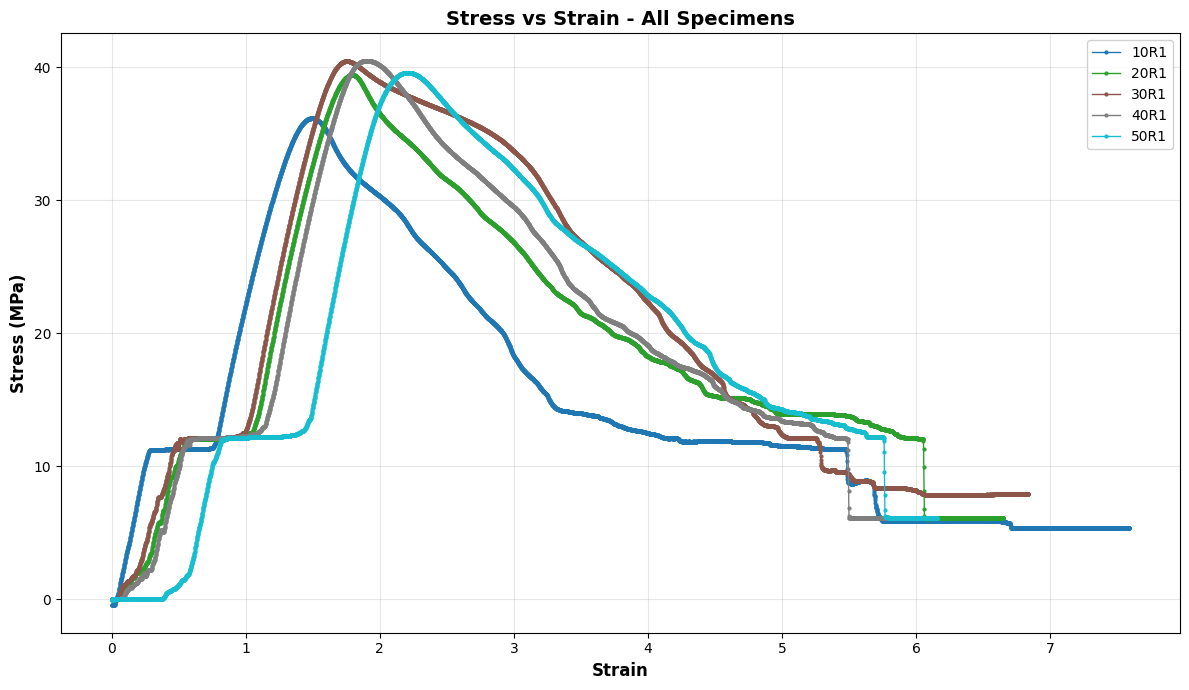

In [69]:
infill_rep1 = ['10R1', '20R1', '30R1', '40R1', '50R1']

def plot_combined(infill_rep1, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_rep1)))
    
    for idx, specimen_id in enumerate(infill_rep1):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna()
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=1, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_combined(infill_rep1, df)

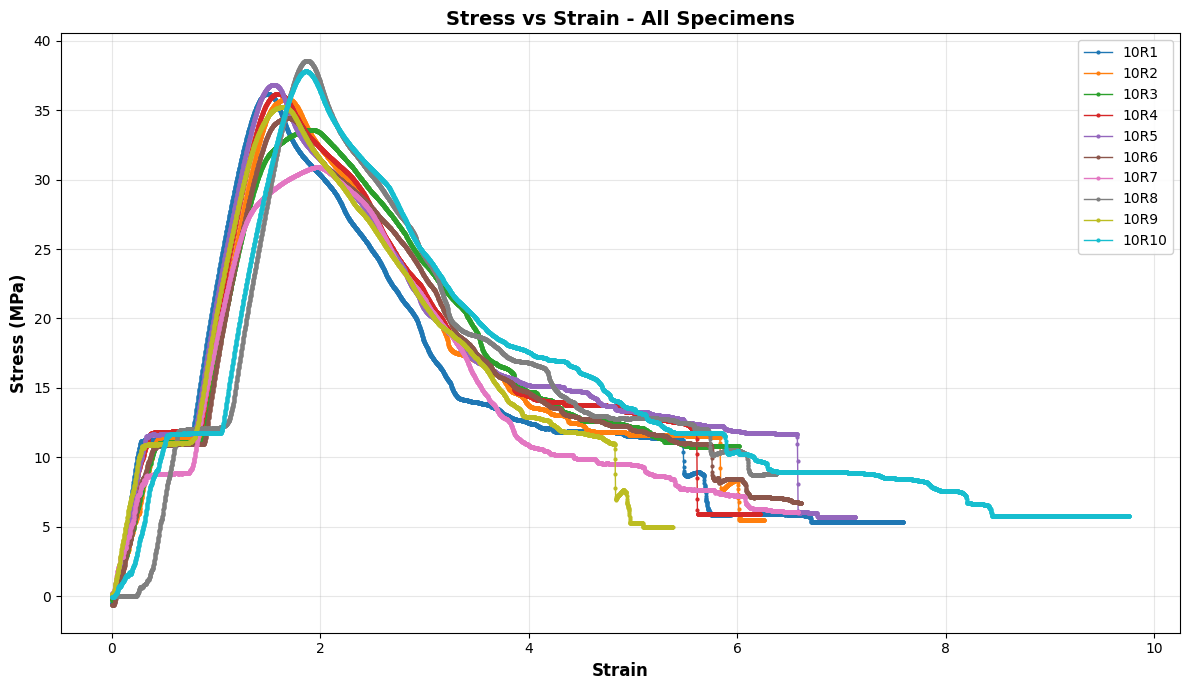

In [ ]:
infill_den10 = ['10R1', '10R2', '10R3', '10R4', '10R5', '10R6', '10R7', '10R8', '10R9', '10R10']

def plot_combined(infill_den10, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_den10)))
    
    for idx, specimen_id in enumerate(infill_den10):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna()
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=1, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_combined(infill_den10, df)

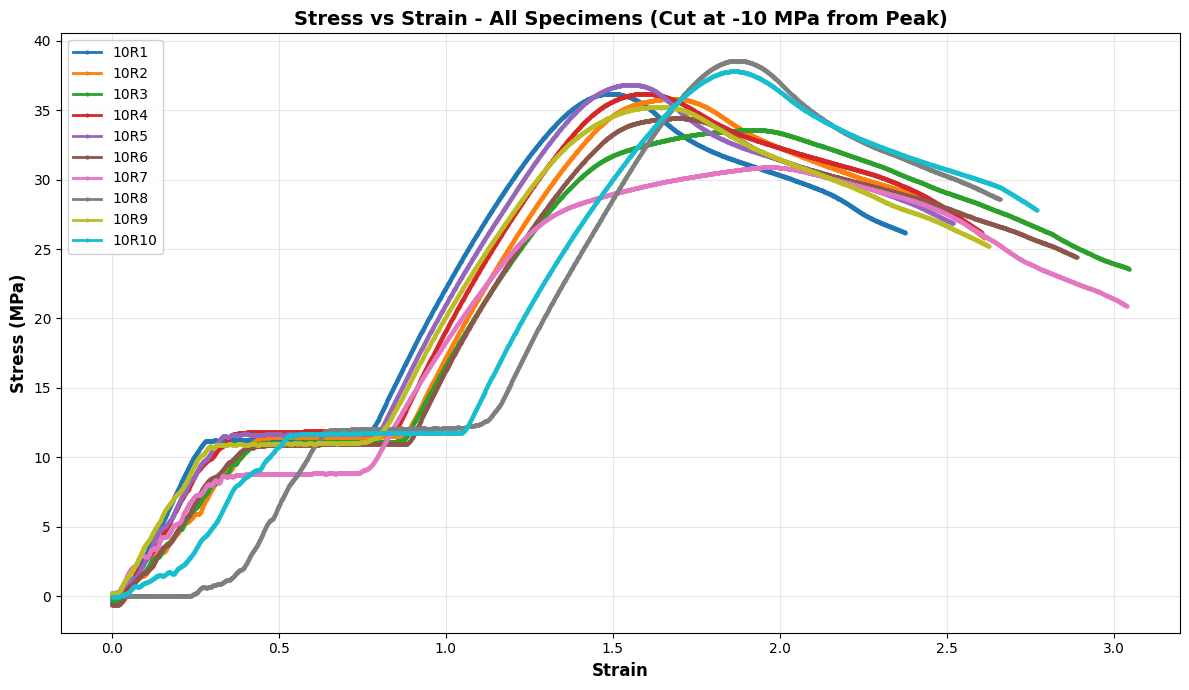

In [72]:
def plot_combined(infill_den10, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_den10)))
    
    for idx, specimen_id in enumerate(infill_den10):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna().reset_index(drop=True)
        
        # Find the peak stress
        max_stress = specimen_data['Stress'].max()
        max_index = specimen_data['Stress'].idxmax()
        
        # Find where stress drops by 10 MPa from peak
        threshold = max_stress - 10
        # Look for the first point after peak where stress drops below threshold
        drop_indices = specimen_data[max_index:][specimen_data[max_index:]['Stress'] < threshold].index
        
        if len(drop_indices) > 0:
            cut_index = drop_indices[0]
            specimen_data = specimen_data[:cut_index]
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=2, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens (Cut at -10 MPa from Peak)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('stress_strain_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function with your dataframe
plot_combined(infill_den10, df)

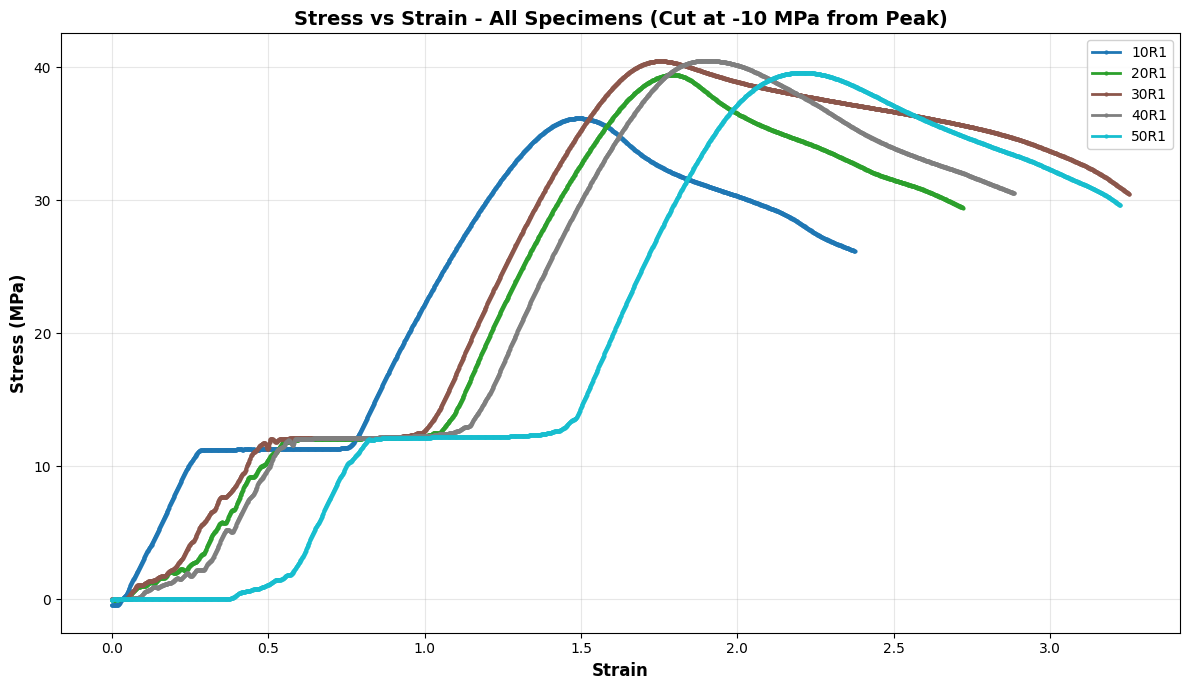

In [ ]:
def plot_combined(infill_rep1, df):
    """Plot all specimens on one graph with different colors"""
    plt.figure(figsize=(12, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(infill_rep1)))
    
    for idx, specimen_id in enumerate(infill_rep1):
        # Extract data for this specimen
        specimen_data = df[specimen_id].dropna().reset_index(drop=True)
        
        # Find the peak stress
        max_stress = specimen_data['Stress'].max()
        max_index = specimen_data['Stress'].idxmax()
        
        # Find where stress drops by 10 MPa from peak
        threshold = max_stress - 10
        # Look for the first point after peak where stress drops below threshold
        drop_indices = specimen_data[max_index:][specimen_data[max_index:]['Stress'] < threshold].index
        
        if len(drop_indices) > 0:
            cut_index = drop_indices[0]
            specimen_data = specimen_data[:cut_index] 
        
        plt.plot(specimen_data['Strain'], specimen_data['Stress'], 
                marker='o', label=specimen_id, 
                color=colors[idx], linewidth=2, markersize=2)
    
    plt.xlabel('Strain', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Stress vs Strain - All Specimens (Cut at -10 MPa from Peak)', fontsize=14, fontweight='bold')
    plt.legend(loc='best', framealpha=0.9, fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('stress_strain_combined.png', dpi=300, bbox_inches='tight')
    plt.show()

# Call the function with your dataframe
plot_combined(infill_rep1, df)